What are the most demanded skills for the top 3 most popular data roles?

Methodology

1. Clean-up skill column
2. Calculate skill count based on "job_title_short"
3. Calculate skill percentage
4. Plot final findings

In [40]:
# Importing Libraries
import ast
import seaborn as sns
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [30]:
df_NL = df[df["job_country"] == "Netherlands"]

In [31]:
df_skills = df_NL.explode("job_skills")

df_skills[["job_title", "job_skills"]]

,job_title,job_skills
121,Senior Data Engineer,python
121,Senior Data Engineer,scala
121,Senior Data Engineer,sql
121,Senior Data Engineer,aws
121,Senior Data Engineer,azure
...,...,...
785528,Data Specialist,r
785528,Data Specialist,sql
785528,Data Specialist,azure
785528,Data Specialist,aws


In [32]:
df_job_title_count = df_NL["job_title_short"].value_counts().reset_index(name="jobs_total")

In [33]:
df_skills_count = df_skills.groupby(["job_skills", "job_title_short"]).size()

df_skills_count = df_skills_count.reset_index(name="skill_count")

df_skills_count.sort_values(by="skill_count", ascending=False, inplace=True)

In [34]:
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, how="left", on="job_title_short")

df_skills_perc["skill_percent"] = 100 * df_skills_perc["skill_count"] / df_skills_perc["jobs_total"]

df_skills_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,sql,Data Engineer,3700,6591,56.137157
1,python,Data Engineer,3613,6591,54.817175
2,azure,Data Engineer,3245,6591,49.233804
3,python,Data Scientist,2661,4167,63.858891
4,sql,Data Analyst,2075,4123,50.327431
...,...,...,...,...,...
1298,asana,Data Scientist,1,4167,0.023998
1299,asana,Senior Data Analyst,1,511,0.195695
1300,wire,Machine Learning Engineer,1,492,0.203252
1301,wire,Senior Data Scientist,1,803,0.124533


In [35]:
job_titles = df_skills_count["job_title_short"].unique().tolist()

job_titles = sorted(job_titles[:3])

job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

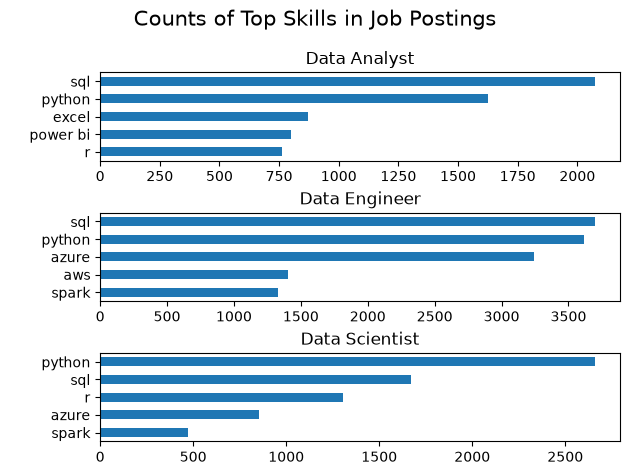

In [36]:
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count["job_title_short"] == job_title].head(5)
    df_plot.plot(kind="barh", x="job_skills", y="skill_count", ax=ax[i], title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel(" ")
    ax[i].legend().set_visible(False)

fig.suptitle("Counts of Top Skills in Job Postings", fontsize=15)
fig.tight_layout(h_pad=0.5)
plt.show()

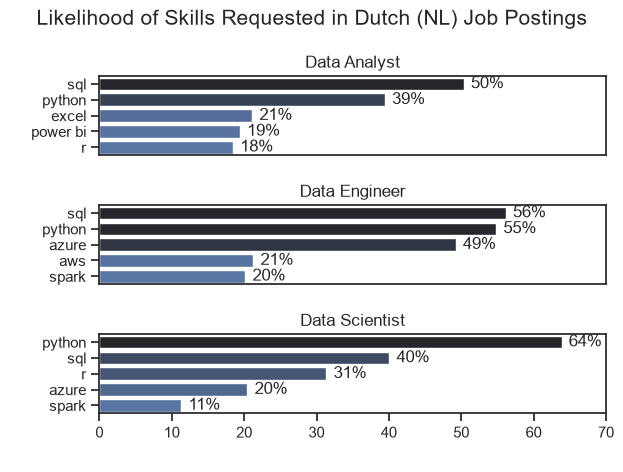

In [54]:
fig, ax = plt.subplots(len(job_titles), 1)

sns.set_theme(style="ticks")
for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc["job_title_short"] == job_title].head(5)
    sns.barplot(data=df_plot, x="skill_percent", y="job_skills", ax=ax[i], hue="skill_count", palette="dark:b_r")
    ax[i].set_title(job_title)
    ax[i].set_xlabel(" ")
    ax[i].set_ylabel(" ")
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 70)

    for n, v in enumerate(df_plot["skill_percent"]):
        ax[i].text(v + 1, n, f"{v:.0f}%", va="center")

    if i != len(job_titles) - 1:
        ax[i].set_xticks([])
fig.suptitle("Likelihood of Skills Requested in Dutch (NL) Job Postings", fontsize=15)
fig.tight_layout(h_pad=0.5)
plt.show()